<a href="https://colab.research.google.com/github/thuynguyenhuit/hocsau/blob/main/Linear_Insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
pd_train = pd.read_csv("https://raw.githubusercontent.com/thuynguyenhuit/hocsau/refs/heads/main/insurance.csv")

(1338, 7)


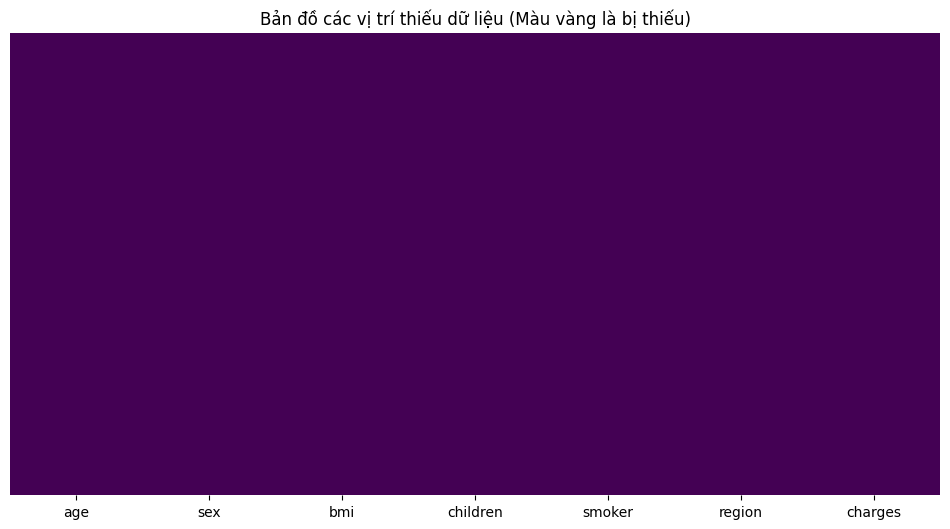

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Kiểm tra sơ bộ kích thước bảng (bao nhiêu hàng, bao nhiêu cột)
print(pd_train.shape)

# 2. Vẽ Heatmap để xem chỗ nào không có dữ liệu (Missing values)
plt.figure(figsize=(12, 6))
sns.heatmap(pd_train.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Bản đồ các vị trí thiếu dữ liệu (Màu vàng là bị thiếu)')
plt.show()

In [3]:
# 1. Đếm số lượng giá trị null cho mỗi cột
null_counts = pd_train.isnull().sum()

# 2. Lọc ra các cột có ít nhất 1 giá trị null để dễ quan sát
missing_data = null_counts[null_counts > 0].sort_values(ascending=False)

# 3. Tính thêm tỉ lệ % để dễ đưa ra quyết định (Xóa hay Bổ sung)
missing_percentage = (null_counts[null_counts > 0] / len(pd_train) * 100).sort_values(ascending=False)

# 4. Hiển thị kết quả dưới dạng bảng
missing_report = pd.DataFrame({'Số dòng thiếu': missing_data, 'Tỉ lệ (%)': missing_percentage})
print(missing_report)

Empty DataFrame
Columns: [Số dòng thiếu, Tỉ lệ (%)]
Index: []


In [ ]:
# Xóa các cột thiếu quá nhiều (>=50%)
pd_train.drop(['Alley', 'PoolQC', 'MiscFeature', 'Fence','MasVnrType','FireplaceQu'], axis=1, inplace=True)

(1460, 75)


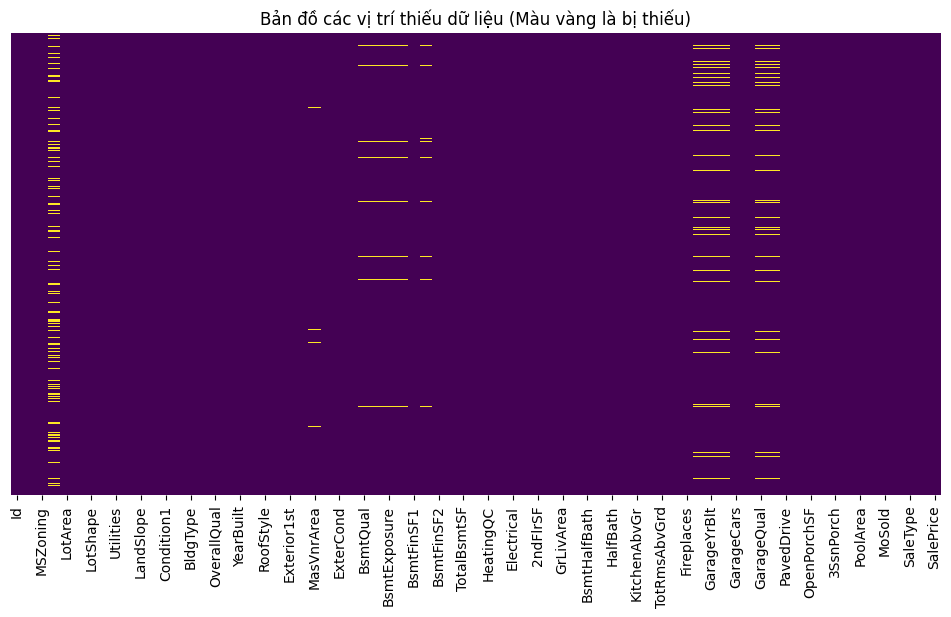

In [ ]:
#Xem lại bản đồ nhiệt
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Kiểm tra sơ bộ kích thước bảng (bao nhiêu hàng, bao nhiêu cột)
print(pd_train.shape)

# 2. Vẽ Heatmap để xem chỗ nào không có dữ liệu (Missing values)
plt.figure(figsize=(12, 6))
sns.heatmap(pd_train.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Bản đồ các vị trí thiếu dữ liệu (Màu vàng là bị thiếu)')
plt.show()

In [ ]:
#hiển thị lại số dòng trên mỗi cột
# 1. Đếm số lượng giá trị null cho mỗi cột
null_counts = pd_train.isnull().sum()

# 2. Lọc ra các cột có ít nhất 1 giá trị null để dễ quan sát
missing_data = null_counts[null_counts > 0].sort_values(ascending=False)

# 3. Tính thêm tỉ lệ % để dễ đưa ra quyết định (Xóa hay Bổ sung)
missing_percentage = (null_counts[null_counts > 0] / len(pd_train) * 100).sort_values(ascending=False)

# 4. Hiển thị kết quả dưới dạng bảng
missing_report = pd.DataFrame({'Số dòng thiếu': missing_data, 'Tỉ lệ (%)': missing_percentage})
print(missing_report)

              Số dòng thiếu  Tỉ lệ (%)
LotFrontage             259  17.739726
GarageYrBlt              81   5.547945
GarageFinish             81   5.547945
GarageQual               81   5.547945
GarageType               81   5.547945
GarageCond               81   5.547945
BsmtFinType2             38   2.602740
BsmtExposure             38   2.602740
BsmtQual                 37   2.534247
BsmtFinType1             37   2.534247
BsmtCond                 37   2.534247
MasVnrArea                8   0.547945
Electrical                1   0.068493


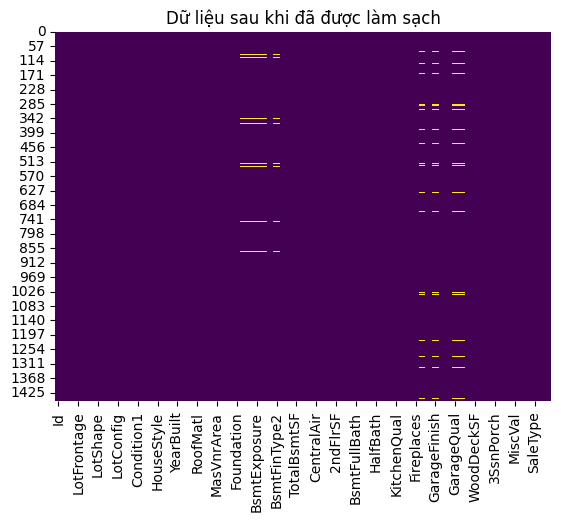

In [ ]:
#Tiếp tục Cột số (Numerical): LotFrontage, GarageYrBlt, MasVnrArea.

# Cách thức: Điền bằng giá trị Median (trung vị). dùng Median thay vì Mean vì Median không bị ảnh hưởng bởi các điểm ngoại lai (outliers).
numeric_cols = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']
for col in numeric_cols:
    pd_train[col] = pd_train[col].fillna(pd_train[col].median())

# Kiểm tra lại bằng Heatmap một lần nữa
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(pd_train.isnull(), cbar=False, cmap='viridis')
plt.title("Dữ liệu sau khi đã được làm sạch các cột số")
plt.show()

Đã điền 'None' cho các cột đặc tính nhà và 'Mode' cho cột Electrical.


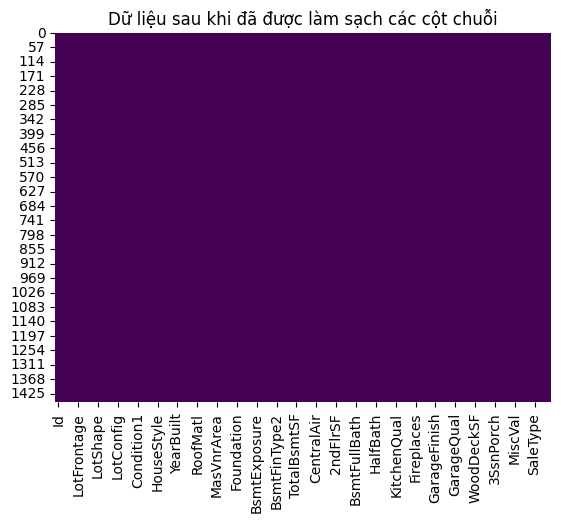

In [ ]:
# Xử lý các cột có kiểu dữ liệu chuỗi
# 1. Danh sách các cột chữ cần điền "None"
categorical_cols_to_none = [
    'GarageFinish', 'GarageType', 'GarageQual', 'GarageCond',
    'BsmtExposure', 'BsmtFinType2', 'BsmtCond', 'BsmtQual', 'BsmtFinType1'
]

# 2. Điền "None" thay vì Mode
for col in categorical_cols_to_none:
    pd_train[col] = pd_train[col].fillna("None")

# 3. Riêng cột 'Electrical' thường mỗi nhà đều phải có điện,
# nên ta vẫn nên điền bằng giá trị phổ biến nhất (Mode)
pd_train['Electrical'] = pd_train['Electrical'].fillna(pd_train['Electrical'].mode()[0])

print("Đã điền 'None' cho các cột đặc tính nhà và 'Mode' cho cột Electrical.")
# Kiểm tra lại bằng Heatmap một lần nữa
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(pd_train.isnull(), cbar=False, cmap='viridis')
plt.title("Dữ liệu sau khi đã được làm sạch các cột chuỗi")
plt.show()

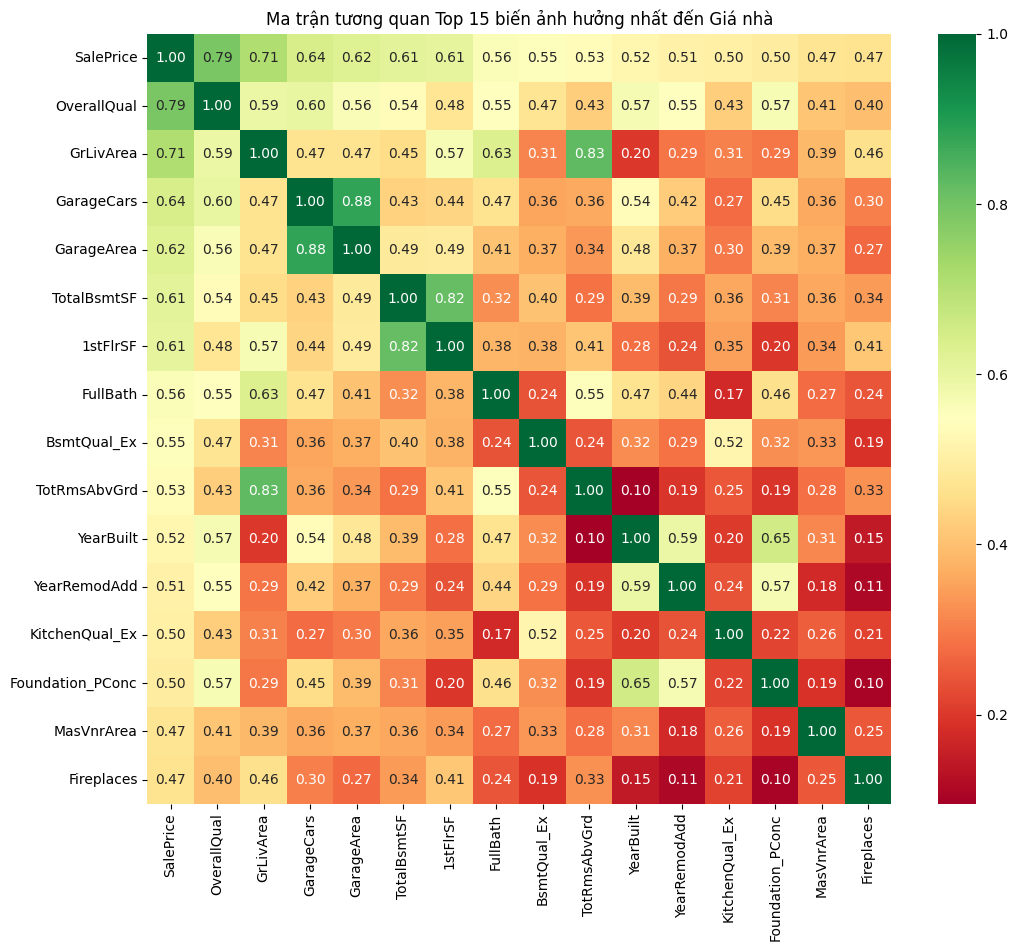

Tương quan của các biến với SalePrice:
SalePrice            1.000000
OverallQual          0.790982
GrLivArea            0.708624
GarageCars           0.640409
GarageArea           0.623431
                       ...   
GarageType_Detchd   -0.354141
GarageFinish_Unf    -0.410608
BsmtQual_TA         -0.452394
KitchenQual_TA      -0.519298
ExterQual_TA        -0.589044
Name: SalePrice, Length: 277, dtype: float64


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Giả sử pd_train là DataFrame bạn đã làm sạch ở các bước trước

# 1. Chuyển đổi toàn bộ các cột chữ sang số (Encoding)
# Hàm get_dummies sẽ tự động chuyển các cột Object thành các cột 0 và 1
pd_numeric = pd.get_dummies(pd_train)

# 2. Tính toán ma trận tương quan
corr_matrix = pd_numeric.corr()

# 3. Lấy ra sự tương quan của tất cả các biến đối với SalePrice
# Sắp xếp từ cao xuống thấp
saleprice_corr = corr_matrix['SalePrice'].sort_values(ascending=False)

# 4. Hiển thị Top 15 biến có tương quan mạnh nhất (để biểu đồ không bị quá dày đặc)
top_features = saleprice_corr.head(16).index
plt.figure(figsize=(12, 10))
sns.heatmap(pd_numeric[top_features].corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Ma trận tương quan Top 15 biến ảnh hưởng nhất đến Giá nhà")
plt.show()

# 5. In ra danh sách đầy đủ các chỉ số tương quan
print("Tương quan của các biến với SalePrice:")
print(saleprice_corr)

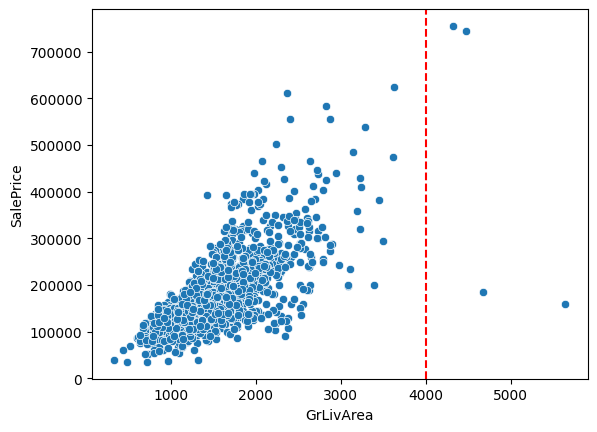

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vẽ để nhìn tận mắt outlier
sns.scatterplot(data=pd_train, x='GrLivArea', y='SalePrice')
plt.axvline(x=4000, color='r', linestyle='--') # Vạch kẻ diện tích 4000
plt.show()



In [ ]:
# Xóa những căn diện tích > 4000 mà giá rẻ (dưới 300k)
pd_train = pd_train.drop(pd_train[(pd_train['GrLivArea']>4000) & (pd_train['SalePrice']<300000)].index)

In [ ]:
# Dùng IQR để làm sạch cột SalePrice
#Cần xem lại bước này

Q1 = pd_train['SalePrice'].quantile(0.25)
Q3 = pd_train['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
# Chỉ giữ lại dữ liệu trong khoảng "bình thường"
pd_train = pd_train[~((pd_train['SalePrice'] < (Q1 - 1.5 * IQR)) | (pd_train['SalePrice'] > (Q3 + 1.5 * IQR)))]

In [ ]:
import pandas as pd

# 1. Cấu hình để hiển thị tối đa số dòng (thay vì bị dấu ...)
pd.set_option('display.max_rows', None)

# 2. Tính toán lại tương quan (nếu bạn chưa lưu biến)
corr_matrix = pd_train.corr(numeric_only=True)
saleprice_corr = corr_matrix['SalePrice'].sort_values(ascending=False)

# 3. In ra - lúc này danh sách sẽ dài dằng dặc từ đầu đến cuối
print(saleprice_corr)

# 4. (Tùy chọn) Reset lại cấu hình mặc định sau khi in xong để tránh rối mắt sau này
pd.reset_option('display.max_rows')

SalePrice        1.000000
OverallQual      0.795774
GrLivArea        0.734968
TotalBsmtSF      0.651153
GarageCars       0.641047
1stFlrSF         0.631530
GarageArea       0.629217
FullBath         0.562165
TotRmsAbvGrd     0.537769
YearBuilt        0.523608
YearRemodAdd     0.507717
MasVnrArea       0.477810
Fireplaces       0.469862
GarageYrBlt      0.467413
BsmtFinSF1       0.409384
LotFrontage      0.352688
WoodDeckSF       0.324758
OpenPorchSF      0.321142
2ndFlrSF         0.320532
HalfBath         0.284590
LotArea          0.268179
BsmtFullBath     0.228459
BsmtUnfSF        0.214460
BedroomAbvGr     0.168245
ScreenPorch      0.111415
PoolArea         0.099490
MoSold           0.046124
3SsnPorch        0.044568
BsmtFinSF2      -0.011422
BsmtHalfBath    -0.016881
MiscVal         -0.021203
Id              -0.021673
LowQualFinSF    -0.025625
YrSold          -0.028882
OverallCond     -0.077948
MSSubClass      -0.084276
EnclosedPorch   -0.128646
KitchenAbvGr    -0.135946
Name: SalePr

In [ ]:
#Chọn các feature có độ tương quan >0.5 làm tập X
# Bước 4: Xác định Features (X)
selected_features = [
    'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
    'FullBath', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'Fireplaces'
]

X = pd_train[selected_features]
y = pd_train['SalePrice']

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Tách dữ liệu: test_size=0.2 tương đương 20% dữ liệu dùng để kiểm tra
# 2. random_state=42: giúp kết quả chia dữ liệu luôn giống nhau mỗi khi bạn chạy lại code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Kiểm tra số lượng dòng của mỗi tập
print(f"Tổng số mẫu: {len(X)}")
print(f"Số mẫu huấn luyện (Train): {len(X_train)}")
print(f"Số mẫu kiểm tra (Test): {len(X_test)}")

Tổng số mẫu: 1458
Số mẫu huấn luyện (Train): 1166
Số mẫu kiểm tra (Test): 292


In [ ]:
from sklearn.linear_model import LinearRegression

# 1. Khởi tạo thuật toán
model = LinearRegression()

# 2. Bắt đầu huấn luyện (Dạy máy học mối quan hệ giữa X_train và y_train)
model.fit(X_train, y_train)

print("Đã huấn luyện xong! Mô hình đã sẵn sàng dự đoán.")

Đã huấn luyện xong! Mô hình đã sẵn sàng dự đoán.


In [ ]:
# Máy thực hiện bài kiểm tra
y_pred = model.predict(X_test)

# Xem thử 5 kết quả dự đoán đầu tiên
print("Giá dự đoán: ", y_pred[:5])
print("Giá thực tế:  ", y_test[:5].values)

Giá dự đoán:  [212725.75627748 115144.94101316 113686.84017625 171224.69353977
 282871.49043675]
Giá thực tế:   [190000 100000 115000 159000 315500]


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Độ chính xác (R2 Score): {r2:.4f}")
print(f"Sai số trung bình (MAE): {mae:,.0f} USD")

Độ chính xác (R2 Score): 0.8225
Sai số trung bình (MAE): 24,059 USD


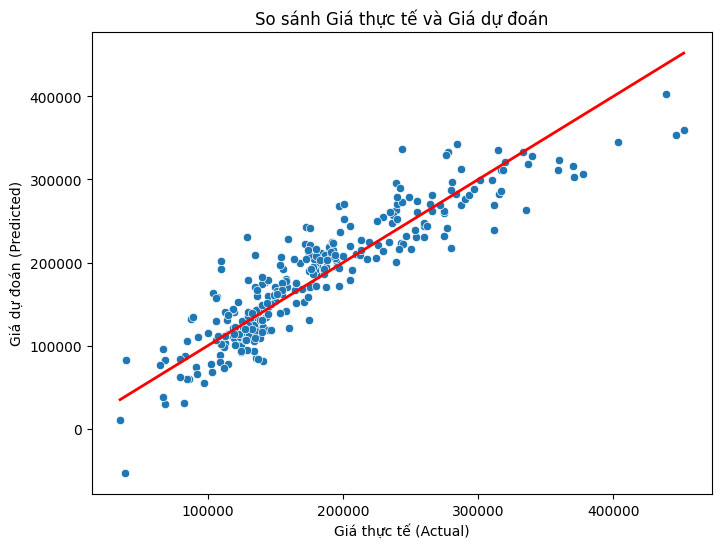

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel("Giá thực tế (Actual)")
plt.ylabel("Giá dự đoán (Predicted)")
plt.title("So sánh Giá thực tế và Giá dự đoán")
plt.show()